In [1]:
using LinearAlgebra
using Plots

Base.@kwdef struct Params
    # geometry
    L::Float64 = 1.0
    N::Int = 512*2
    dx::Float64 = L/(N-1)

    # time
    T::Int = 200
    dt::Float64 = 1e-3

    # phase field
    l::Float64 = 0.01
    kappa::Float64 = 1e-6

    # material
    ν::Float64 = 0.3
    A::Float64 = 1.0
    n::Int = 3
    C2::Float64 = 1.0
    C3::Float64 = 1.0

    # numerics
    tol::Float64 = 1e-6
    max_iter::Int = 30

    # critical energy for damage
    psi_crit::Float64 = 1e-2

    savefile::String = "viscoelastic_1d.jls"
end

Params

In [2]:
# ============================================================
# Material properties
# ============================================================

# Young's modules tuned by Poisson ratio ν to satisfy mass balance
E(p) = 2*(1+p.ν)^2/(1-p.ν)

# Lame Parameters
λ(p) = E(p)*p.ν / ((1+p.ν)*(1-2p.ν))
μ(p) = E(p)/(2*(1+p.ν))


# ============================================================
# Utilities
# ============================================================

# Gaussian
function gaussian(x, x0, width, amp)
    return amp * exp.(-(x.-x0).^2 ./ (2*width^2))
end

# ⟨x⟩_+
positive(x) = 0.5 * (x + abs(x))

# centred FD with forward/backward on ends
function DfDx(f::Vector, p::Params)
    N = p.N
    dx = p.dx
    fx = zeros(N)
    fx[1] = (f[2]-f[1])/dx
    for i in 2:N-1
        fx[i] = (f[i+1]-f[i-1])/(2dx)
    end
    fx[N] = (f[N]-f[N-1])/dx
    return fx
end

# centred FD with forward/backward on ends
function DfDxx(f::Vector, p::Params)
    N = p.N
    dx = p.dx
    idx = 1/dx
    fxx = zeros(N)
    fxx[1] = (2*f[1]-5*f[2]+4*f[3]-f[4])*idx^2
    for i in 2:N-1
        fxx[i] = (f[i+1]-2*f[i]+f[i-1])*idx^2
    end
    fxx[N] = (2*f[N]-5*f[N-1]+4*f[N-2]-f[N-3])*idx^2
    return fxx
end

# midpoint
# stagav(f)_[i]=f_{i+1/2}, stagav(f)_[i-1]=f_{i-1/2} 
stagav(f) = 0.5 .* (f[1:end-1] .+ f[2:end])

# degradation function
g(d,p) = (1 .- d).^2 .+ p.kappa

# ============================================================
# Effective stiffness K̄(d, a_x), 
# with a_x = u_x - w_x (elastic displacement)
# ============================================================

function Kbar(ax, d, p)
    K0 = λ(p)/2 + μ(p)/3 + 4/3
    gval = g(d,p)
    K = similar(ax)
    for i in eachindex(d)
        if ax[i] > 0
            K[i] = 2*gval[i]*K0
        else
            K[i] = 2*K0
        end
    end
    return K
end

# ============================================================
# Glen viscosity coefficients
# ============================================================

function Fcoef(ax, d, p)
    gval = g(d,p)
    n = p.n
    A = p.A
    C2 = p.C2
    F = similar(d)
    for i in eachindex(d)
        if ax[i] > 0
            F[i] = 2^((1+n)/2)*A*
                   (C2*(16/9 + 8/(9*gval[i])))^n
        else
            F[i] = 2^((1+n)/2)*A*
                   (C2*(8/9 + 16/(9*gval[i])))^n
        end
    end
    return F
end


function Gcoef(ax, p)
    n = p.n
    return ax.^(n-1)
end

Gcoef (generic function with 1 method)

In [35]:
function get_matrix(u_old, w_old, d, ubarL, ubarR, p::Params)
    N  = p.N
    dx = p.dx
    idx = 1/dx
    dt = p.dt
    n = p.n

    u = copy(u_old)
    w = copy(w_old)

    res = 0.0
    ii = 0
    M = zeros(2*p.N,2*p.N)

    for iter in 1:p.max_iter
        # elastic strain
        a = u .- w
        ax = DfDx(a,p)

        # coefficients
        K = Kbar(ax,d,p)
        Kmid = stagav(K)

        F = Fcoef(ax,d,p)
        G = Gcoef(ax,p)
        Fmid = stagav(F)
        Gmid = stagav(G)
        Fx = DfDx(F, p)
        #Gx = DfDx(G, p)
        Gx = (n-1)*ax.^(n-2) .*DfDxx(a,p)

        # --------------------------------------------------
        # Allocate blocks
        # --------------------------------------------------
        A = zeros(N,N)
        B = zeros(N,N)
        C = zeros(N,N)
        D = zeros(N,N)

        a = zeros(N)
        c = zeros(N)

        # --------------------------------------------------
        # Boundary conditions (u)
        # --------------------------------------------------
        A[1,1] = 1.0
        a[1]   = 0.0#ubarL

        # # to prescribe displacement
        # A[N,N] = 1.0
        # a[N] = ubarR
        # to prescribe traction
        A[N,N] = 1.0/dx
        A[N,N-1] = -1.0/dx
        B[N,N] = -1.0/dx
        B[N,N-1] = 1.0/dx
        a[N]   = ubarR/K[N] # ubar is traction here

        # dirichlet for w(0)=0; acts as gauge fixing since we evolve w_x
        D[1,1] = 1.0
        c[1] = 0.0

        # # if displacement is prescribed
        # # right end
        # D[N,N] = 1.0/dx
        # D[N,N-1] = -1.0/dx
        # # (u_x - w_x) = t/Kbar; calc u_x-w_x from old sol. with backward FD
        # u_x_minus_w_x_old = (u_old[N] - u_old[N-1])/dx - (w_old[N]-w_old[N-1])/dx
        # c[N] = (w_old[N] - w_old[N-1])/dx + dt*F[N]*G[N]*(u_x_minus_w_x_old)

        # if traction is prescribed
        # right end
        D[N,N] = 1.0/dx #(Fmid[end]*Gmid[end]*dt - (F[N]*Gx[N] + Fx[N]*G[N])*dt*dx) / (-dx)
        D[N,N-1] = -1.0/dx #Fmid[end]*Gmid[end]*dt / dx
        #C[N,N-1] = (-Fmid[end]*Gmid[end]*dt) / dx
        #C[N,N] = (-Fmid[end]*Gmid[end]*dt + F[N]*Gx[N]*dt*dx + Fx[N]*G[N]*dt*dx) / (-dx)
        c[N] = (w_old[N] - w_old[N-1])/dx + dt*F[N]*G[N]*(ubarR/K[N])
        #c[N] = c[N] + (w_old[N] - w_old[N-1])/(2*dx)

        # --------------------------------------------------
        # Interior nodes
        # ---------------------------------------------------
        for i in 2:N-1
            im = i-1
            ip = i+1

            # m=minus=i-1/2, p=plus=i+1/2
            km = Kmid[i-1]
            kp = Kmid[i]
            Fm = Fmid[i-1]
            Fp = Fmid[i]
            Gm = Gmid[i-1]
            Gp = Gmid[i]

            # ===== Momentum equation =====
            A[i,im] =  km#*idx^2
            A[i,i]  = -(km+kp)#*idx^2
            A[i,ip] =  kp#*idx^2

            B[i,im] = -km#*idx^2
            B[i,i]  =  (km+kp)#*idx^2
            B[i,ip] = -kp#*idx^2

            # ===== Viscosity equation =====
            C[i,im] =  0.5*dt*Fm*Gm
            C[i,i]  = -dt*(0.5*Fp*Gp-0.5*Fm*Gm-dx*(Fx[i]*G[i]+F[i]*Gx[i]))
            C[i,ip] = -0.5*dt*Fp*Gp

            D[i,im] = -0.5*(1 + dt*Fm*Gm)
            D[i,i]  = -dt*(0.5*Fp*Gp-0.5*Fm*Gm-dx*(Fx[i]*G[i]+F[i]*Gx[i]))
            D[i,ip] =  0.5*(1 + dt*Fp*Gp)

            # RHS
            c[i] = (w_old[ip] - w_old[im]) / 2
        end

        # # for the last row of w we integrate the viscocity eq in the whole domain
        # C[N,1] = dt*(F[1]G[1]+Fx[1]*G[1]+F[1]*Gx[1])
        # C[N,N] = dt*(-F[N]G[N]+Fx[N]*G[N]+F[N]*Gx[N]) 
        # D[N,1] = -1.0+dt*(-F[1]G[1]+Fx[1]*G[1]+F[1]*Gx[1])
        # D[N,N] = 1.0+dt*(F[1]G[1]+Fx[1]*G[1]+F[1]*Gx[1])
        # for i in 2:N-1
        #     C[N,i] = dt*(Fx[i]*G[i]+F[i]*Gx[i])
        #     D[N,i] = -dt*(Fx[i]*G[i]+F[i]*Gx[i])
        # end
        # C[N] = w_old[N] - w_old[1]

        #--------------------------------------------------
        #Assemble full system
        # --------------------------------------------------
        M = [A  B;
             C  D]

        rhs = [a; c]

        sol = M \ rhs

        u_new = sol[1:N]
        w_new = sol[N+1:end]

        res = maximum(abs.(u_new-u)) + maximum(abs.(w_new-w))
        ii+=1
        println("res = $(round(res, sigdigits=4)) iter = $ii")

        u .= u_new
        w .= w_new

        if res < p.tol
            break
        end
    end

    return M, u, w#A,B,C,D,a,c 
end

get_matrix (generic function with 1 method)

In [56]:
p = Params(N=100*8, dt=1e-2)
x = range(0,p.L,p.N)

u = 0.0 .* collect(x).^0.5#gaussian(x, p.L/2, 0.05, 0.2)#zeros(p.N)
w = 0.0 .* collect(x).^2#0.01*gaussian(x, p.L/2, 0.05, 0.2)#zeros(p.N)
d = 0.1*gaussian(x, p.L/2, 0.05, 0.2)#0.01*rand(p.N)
H = zeros(p.N);

In [57]:
ubarL, ubarR = (0.0, 0.1) 
M, unew, wnew = get_matrix(u,w,d,ubarL,ubarR,p)
#A,B,C,D,a,c = get_matrix(u,w,d,ubarL,ubarR,p)

res = 0.01495 iter = 1
res = 8.166e-5 iter = 2
res = 5.579e-8 iter = 3


([1.0 0.0 … 0.0 0.0; 6.69048288095238 -13.38096576190476 … 0.0 0.0; … ; 0.0 0.0 … 4.715654650031284e-17 0.5000847268051694; 0.0 0.0 … -799.0 799.0], [2.0329270394157153e-19, 1.870980854386101e-5, 3.7419617087724454e-5, 5.612942563158526e-5, 7.48392341754487e-5, 9.354904271930952e-5, 0.00011225885126317296, 0.00013096865980703377, 0.0001496784683508972, 0.00016838827689475802  …  0.014857358917184338, 0.014876068725728189, 0.014894778534272035, 0.014913488342815886, 0.014932198151359731, 0.01495090795990358, 0.014969617768447423, 0.01498832757699127, 0.015007037385535113, 0.01502574719407896], [0.0, 3.1699074529264284e-9, 6.339814908490709e-9, 9.509722361417138e-9, 1.2679629816981409e-8, 1.5849537269907847e-8, 1.9019444725472118e-8, 2.2189352178398503e-8, 2.535925963396293e-8, 2.8529167086889037e-8  …  2.5585799608896845e-6, 2.561749868345577e-6, 2.56491977579746e-6, 2.5680896832545224e-6, 2.57125959070617e-6, 2.574429498162528e-6, 2.577599405615114e-6, 2.5807693130707665e-6, 2.58393922

In [26]:
aa=dot(C[p.N,:],unew)

LoadError: UndefVarError: `C` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
bb=dot(D[p.N,:],wnew)

LoadError: UndefVarError: `D` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
aa+bb

-1.0842021724855044e-19

In [ ]:
M = [A B; C D]
rhs = [a;c]
sol = M \ rhs
unew = sol[1:p.N]
wnew = sol[p.N+1:2*p.N]
println(unew)
println(wnew)

LoadError: UndefVarError: `A` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

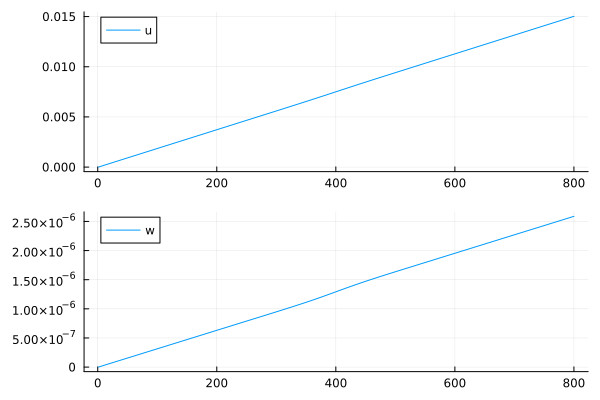

In [58]:
p1 = plot(unew, label="u")
p2 = plot(wnew, label="w")
plot(p1, p2, layout = (2, 1))

In [59]:
function res_eq1(u,w,d,p)
    a = u .- w
    ax = DfDx(a,p)
    K = Kbar(ax,d,p)
    res = DfDx(K.*ax,p)
    return res
end

function res_eq2(u,w,wdot,d,p)
    a = u .- w
    ax = DfDx(a,p)
    F = Fcoef(ax,d,p)
    wdotx = DfDx(wdot,p)
    res = wdotx .- F.*ax.^p.n
    return res
end

res_eq2 (generic function with 1 method)

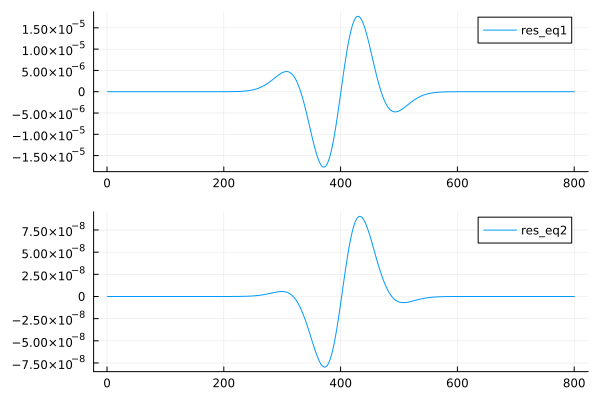

In [60]:
res1 = res_eq1(unew,wnew,d,p)
wdot = (wnew .- w)/p.dt;
res2 = res_eq2(unew,wnew,wdot,d,p)

p1 = plot(res1, label="res_eq1")
p2 = plot(res2, label="res_eq2")
plot(p1, p2, layout = (2, 1))

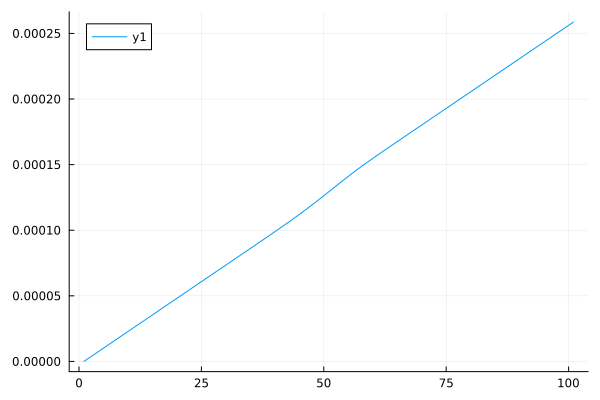

In [26]:
plot(wdot)

In [27]:
res2

101-element Vector{Float64}:
  4.9424440234924205e-15
 -1.7889335846010823e-18
 -1.7889335846010823e-18
 -2.4936649967166602e-18
 -1.7889335846010823e-18
 -1.5720931501039814e-18
 -1.463672932855431e-18
 -9.75781955236954e-19
 -8.239936510889834e-18
  1.2088854223213374e-17
 -9.75781955236954e-19
  1.734723475976807e-17
  9.93129189996722e-17
  ⋮
 -5.421010862427522e-19
 -4.0223900599212215e-16
  6.746990119377294e-16
 -5.362463945113305e-16
  4.202367620553815e-16
 -5.481184083000468e-16
  2.86392003862046e-16
  5.5294310796760726e-18
 -1.4354836763708079e-16
  2.9284300678833475e-16
 -1.5341460740669888e-16
 -7.047314121155779e-18

In [28]:
nn = 1000

xx = collect(range(0.0, 2, nn))
dxx = xx[2] - xx[1]
m = zeros(nn,nn)
r = xx.^1

r[1] = 0.0
r[nn] = 0.5*r[nn]^2

m[1,1] = 1
#m[1,1] = -1
#m[1,2] = 1
m[nn,nn] = 1 
#m[nn,nn] = 1/dxx
#m[nn,nn-1] = -1/dxx
for i in 2:nn-1
    m[i,i-1] = -0.5/dxx
    m[i,i+1] = 0.5/dxx
end

f = m \ r

1000-element Vector{Float64}:
 2.7826502712235827e-15
 2.0040060061345946e-6
 8.016024034822698e-6
 1.803605407021469e-5
 3.206409613094284e-5
 5.010015019837488e-5
 7.214421629114308e-5
 9.819629439061516e-5
 0.00012825638451542342
 0.00016232448664693554
 0.00020040060080378383
 0.00024248472696733602
 0.00028857686515622435
 ⋮
 1.9561984406829258
 1.9601603605607607
 1.9641262884506134
 1.9680962243524804
 1.972070168266365
 1.9760481201922642
 1.980030080130181
 1.9840160480801121
 1.9880060240420607
 1.992000008016024
 1.9959980000020046
 2.0

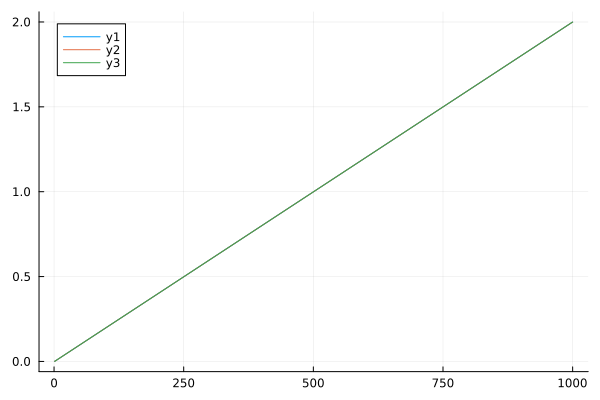

In [29]:
function fd(f::Vector, x::Vector)
    N = length(f)
    dx = x[2]-x[1]
    fx = zeros(N)
    fx[1] = (f[2]-f[1])/dx
    for i in 2:N-1
        fx[i] = (f[i+1]-f[i-1])/(2dx)
    end
    fx[N] = (f[N]-f[N-1])/dx
    return fx
end

plot(r)
plot!(fd(0.5*r.^2,xx))
plot!(fd(f,xx))

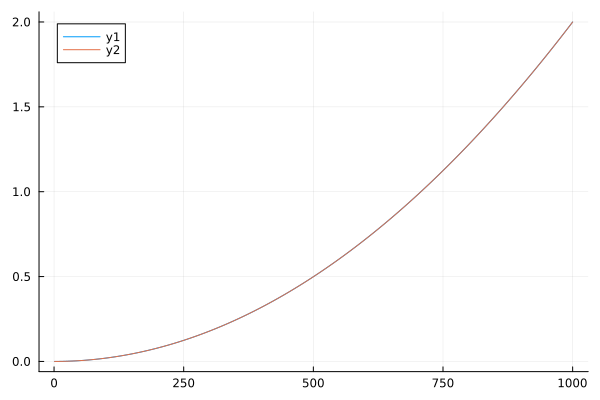

In [208]:
plot(f)
plot!(0.5*r.^2)